# Week 06 Bonus — Real Data Practice

## 1. The German Credit Dataset

This notebook applies the Week 06 machine-learning pipeline to the
Statlog German Credit dataset, a real-world credit-risk classification
dataset.

The purpose of this exercise is to apply the classification workflow to
real data rather than a controlled synthetic dataset. The workflow includes
dataset diagnosis, feature engineering, train/test splitting, baseline
evaluation, model training, model comparison, error analysis, calibration,
and final reflection.

Unlike the synthetic datasets used earlier in the week, the relationships
between the features and target are not known in advance. Therefore, model
selection will be based on evidence from held-out test data rather than a
predefined expected result.

## 2. Import Libraries and Configure the Notebook

The notebook uses pandas and NumPy for data manipulation, matplotlib for
visualization, and scikit-learn for dataset loading, preprocessing,
modeling, evaluation, and calibration.

A dedicated output directory is also created so that generated charts can
be saved alongside the notebook results.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from IPython.display import display, Markdown

from sklearn.datasets import fetch_openml
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import calibration_curve


In [9]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

## 3. Load the German Credit Dataset

The Statlog German Credit dataset is loaded through scikit-learn's
OpenML connector.

The dataset contains credit applications together with a binary target
indicating whether each application represents a good or bad credit risk.

The dataset is loaded as a pandas DataFrame so that the categorical and
numerical features can be inspected directly before preprocessing.

In [10]:
credit = fetch_openml(
    name="credit-g",
    version=1,
    as_frame=True,
    parser="auto"
)

df = credit.frame

In [11]:
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


## 4. Dataset Dimensions

The shape of the loaded DataFrame is checked to verify the number of
observations and columns before beginning the modeling pipeline.

In [12]:
rows, columns = df.shape

display(
    Markdown(
        f"""
The dataset contains **{rows:,} rows** and **{columns} columns**.
"""
    )
)


The dataset contains **1,000 rows** and **21 columns**.


## 5. Dataset Structure

The structure of the dataset is inspected to understand the available
features, their data types, and whether the target is represented as a
categorical variable.

This step is particularly important for the German Credit dataset because
many of its predictors are categorical and therefore require appropriate
encoding before model training.

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   category
 1   duration                1000 non-null   int64   
 2   credit_history          1000 non-null   category
 3   purpose                 1000 non-null   category
 4   credit_amount           1000 non-null   int64   
 5   savings_status          1000 non-null   category
 6   employment              1000 non-null   category
 7   installment_commitment  1000 non-null   int64   
 8   personal_status         1000 non-null   category
 9   other_parties           1000 non-null   category
 10  residence_since         1000 non-null   int64   
 11  property_magnitude      1000 non-null   category
 12  age                     1000 non-null   int64   
 13  other_payment_plans     1000 non-null   category
 14  housing                 1000 non-nul

In [14]:
df.dtypes

checking_status           category
duration                     int64
credit_history            category
purpose                   category
credit_amount                int64
savings_status            category
employment                category
installment_commitment       int64
personal_status           category
other_parties             category
residence_since              int64
property_magnitude        category
age                          int64
other_payment_plans       category
housing                   category
existing_credits             int64
job                       category
num_dependents               int64
own_telephone             category
foreign_worker            category
class                     category
dtype: object

## 6. Numerical Descriptive Statistics

Descriptive statistics are calculated for the numerical variables to
understand their distributions, ranges, and central tendencies.

This provides an initial understanding of the scale of the numerical
features before preprocessing and modeling.

In [15]:
df.describe()

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


## 7. Complete Dataset Summary

A complete descriptive summary is generated to include both numerical and
categorical columns.

For categorical features, the summary helps identify the number of unique
categories and the most frequently occurring category. This is useful for
planning the feature-engineering stage.

In [16]:
df.describe(include="all")

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
count,1000,1000.000000,1000,1000,1000.000000,1000,1000,1000.000000,1000,1000,...,1000,1000.000000,1000,1000,1000.000000,1000,1000.000000,1000,1000,1000
unique,4,NaN,5,10,NaN,5,5,NaN,4,3,...,4,NaN,3,3,NaN,4,NaN,2,2,2
top,no checking,NaN,existing paid,radio/tv,NaN,<100,1<=X<4,NaN,male single,none,...,car,NaN,none,own,NaN,skilled,NaN,none,yes,good
freq,394,NaN,530,280,NaN,603,339,NaN,548,907,...,332,NaN,814,713,NaN,630,NaN,596,963,700
mean,NaN,20.903000,NaN,NaN,3271.258000,NaN,NaN,2.973000,NaN,NaN,...,NaN,35.546000,NaN,NaN,1.407000,NaN,1.155000,NaN,NaN,NaN
std,NaN,12.058814,NaN,NaN,2822.736876,NaN,NaN,1.118715,NaN,NaN,...,NaN,11.375469,NaN,NaN,0.577654,NaN,0.362086,NaN,NaN,NaN
min,NaN,4.000000,NaN,NaN,250.000000,NaN,NaN,1.000000,NaN,NaN,...,NaN,19.000000,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN,NaN
25%,NaN,12.000000,NaN,NaN,1365.500000,NaN,NaN,2.000000,NaN,NaN,...,NaN,27.000000,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN,NaN
50%,NaN,18.000000,NaN,NaN,2319.500000,NaN,NaN,3.000000,NaN,NaN,...,NaN,33.000000,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN,NaN
75%,NaN,24.000000,NaN,NaN,3972.250000,NaN,NaN,4.000000,NaN,NaN,...,NaN,42.000000,NaN,NaN,2.000000,NaN,1.000000,NaN,NaN,NaN


## 8. Feature Type Identification

The columns are separated into numerical and categorical features based on
their pandas data types.

This distinction will determine how each group is handled during feature
engineering.

In [17]:
numerical_columns = df.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

display(
    Markdown(
        f"""
The dataset contains **{len(numerical_columns)} numerical columns** and
**{len(categorical_columns)} categorical columns**.

### Numerical Features

{", ".join(numerical_columns)}

### Categorical Features

{", ".join(categorical_columns)}
"""
    )
)


The dataset contains **7 numerical columns** and
**14 categorical columns**.

### Numerical Features

duration, credit_amount, installment_commitment, residence_since, age, existing_credits, num_dependents

### Categorical Features

checking_status, credit_history, purpose, savings_status, employment, personal_status, other_parties, property_magnitude, other_payment_plans, housing, job, own_telephone, foreign_worker, class


## 9. Categorical Feature Distributions

The unique value distributions of the categorical features are inspected
individually.

This is necessary before encoding because categorical variables may contain
different numbers of levels, and some categories may be rare. The inspection
also helps identify features that may require grouping or special
consideration.

In [18]:
for column in categorical_columns:
    print(f"\n{'=' * 70}")
    print(f"{column}")
    print(f"{'=' * 70}")
    display(df[column].value_counts())


checking_status


checking_status
no checking    394
<0             274
0<=X<200       269
>=200           63
Name: count, dtype: int64


credit_history


credit_history
existing paid                     530
critical/other existing credit    293
delayed previously                 88
all paid                           49
no credits/all paid                40
Name: count, dtype: int64


purpose


purpose
radio/tv               280
new car                234
furniture/equipment    181
used car               103
business                97
education               50
repairs                 22
domestic appliance      12
other                   12
retraining               9
Name: count, dtype: int64


savings_status


savings_status
<100                603
no known savings    183
100<=X<500          103
500<=X<1000          63
>=1000               48
Name: count, dtype: int64


employment


employment
1<=X<4        339
>=7           253
4<=X<7        174
<1            172
unemployed     62
Name: count, dtype: int64


personal_status


personal_status
male single           548
female div/dep/mar    310
male mar/wid           92
male div/sep           50
Name: count, dtype: int64


other_parties


other_parties
none            907
guarantor        52
co applicant     41
Name: count, dtype: int64


property_magnitude


property_magnitude
car                  332
real estate          282
life insurance       232
no known property    154
Name: count, dtype: int64


other_payment_plans


other_payment_plans
none      814
bank      139
stores     47
Name: count, dtype: int64


housing


housing
own         713
rent        179
for free    108
Name: count, dtype: int64


job


job
skilled                      630
unskilled resident           200
high qualif/self emp/mgmt    148
unemp/unskilled non res       22
Name: count, dtype: int64


own_telephone


own_telephone
none    596
yes     404
Name: count, dtype: int64


foreign_worker


foreign_worker
yes    963
no      37
Name: count, dtype: int64


class


class
good    700
bad     300
Name: count, dtype: int64

## 10. Target Distribution

The distribution of the target variable is examined to determine the
proportion of good and bad credit-risk applications.

This is especially important because the dataset is imbalanced. A majority
class baseline can therefore achieve substantial accuracy without learning
meaningful relationships between the predictors and the target.

In [19]:
target_counts = df["class"].value_counts()

display(target_counts)

class
good    700
bad     300
Name: count, dtype: int64

In [20]:
target_percentages = (
    df["class"]
    .value_counts(normalize=True)
    .mul(100)
)

display(
    Markdown(
        f"""
The target distribution is:

{target_percentages.to_string(float_format=lambda x: f"{x:.2f}%")}
"""
    )
)


The target distribution is:

class
good   70.00%
bad    30.00%


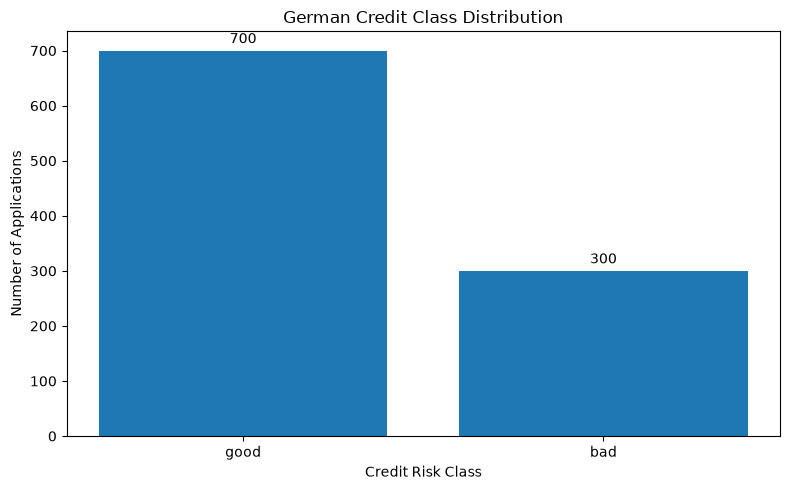

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

target_bars = ax.bar(
    target_counts.index,
    target_counts.values
)

ax.bar_label(
    target_bars,
    padding=3
)

ax.set_title("German Credit Class Distribution")
ax.set_xlabel("Credit Risk Class")
ax.set_ylabel("Number of Applications")

fig.tight_layout()

chart_path = output_dir / "german_credit_class_distribution.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 11. Data Quality Check

The dataset is checked for missing values and duplicate rows.

Although the task description indicates that the dataset should already be
clean at the row level, explicitly verifying these conditions follows the
same diagnostic discipline used throughout the Week 06 pipeline.

In [22]:
total_missing = df.isna().sum().sum()
duplicate_count = df.duplicated().sum()

display(
    Markdown(
        f"""
The dataset contains **{total_missing} missing values** across all columns
and **{duplicate_count} duplicate rows**.
"""
    )
)


The dataset contains **0 missing values** across all columns
and **0 duplicate rows**.


In [23]:
missing_by_column = df.isna().sum()

display(
    missing_by_column[missing_by_column > 0]
)

Series([], dtype: int64)

In [24]:
missing_columns_count = (
    (df.isna().sum() > 0).sum()
)

unique_target_classes = df["class"].nunique()

display(
    Markdown(
        f"""
### 12 Finding

The dataset contains **{rows:,} observations** across **{columns} columns**,
with **{len(numerical_columns)} numerical features** and
**{len(categorical_columns)} categorical features**.

The dataset contains **{total_missing} missing values** and
**{duplicate_count} duplicate rows**.

The target contains **{unique_target_classes} distinct classes**, and its
distribution shows that the classes are not equally represented. This class
imbalance means that the majority-class baseline must be established before
judging whether more complex models provide meaningful improvement.
"""
    )
)


### 12 Finding

The dataset contains **1,000 observations** across **21 columns**,
with **7 numerical features** and
**14 categorical features**.

The dataset contains **0 missing values** and
**0 duplicate rows**.

The target contains **2 distinct classes**, and its
distribution shows that the classes are not equally represented. This class
imbalance means that the majority-class baseline must be established before
judging whether more complex models provide meaningful improvement.


## 13. Feature Engineering Decisions

Unlike the synthetic datasets used earlier in the week, the German Credit
dataset contains many categorical predictors with different numbers of
levels.

Feature engineering therefore requires decisions about:

- How the target should be encoded
- Which categorical variables should be retained
- Whether rare categories should be grouped
- How `personal_status` should be handled
- How categorical variables should be encoded for the models

The goal is to make these decisions explicitly rather than applying
preprocessing blindly.

## 14. Target Encoding

The target variable contains two categories: `good` and `bad`.

For this notebook, `good` is defined as the positive class and encoded as
1, while `bad` is encoded as 0.

This makes the predicted probability directly interpretable as the model's
estimated probability that an applicant represents a good credit risk.

In [25]:
df["target"] = (
    df["class"]
    .map({
        "good": 1,
        "bad": 0
    })
    .astype(int)
)

df[["class", "target"]].head()

,class,target
0,good,1
1,bad,0
2,good,1
3,good,1
4,bad,0


In [26]:
target_mapping_check = (
    df.groupby("class")["target"]
    .agg(["min", "max", "count"])
)

display(target_mapping_check)

,min,max,count
class,,,
bad,0,0,300
good,1,1,700


In [27]:
positive_count = (df["target"] == 1).sum()
negative_count = (df["target"] == 0).sum()

positive_percentage = df["target"].mean() * 100
negative_percentage = 100 - positive_percentage

display(
    Markdown(
        f"""
After encoding, the positive class (`good`) contains **{positive_count:,}**
observations (**{positive_percentage:.2f}%**), while the negative class
(`bad`) contains **{negative_count:,}** observations
(**{negative_percentage:.2f}%**).
"""
    )
)


After encoding, the positive class (`good`) contains **700**
observations (**70.00%**), while the negative class
(`bad`) contains **300** observations
(**30.00%**).


## 15. Separate Predictors from the Target

The original `class` column and the encoded `target` column are excluded
from the predictors.

The remaining variables represent the information available to the model
when making a credit-risk prediction.

In [28]:
feature_columns = [
    column
    for column in df.columns
    if column not in ["class", "target"]
]

X = df[feature_columns].copy()
y = df["target"].copy()

display(
    Markdown(
        f"""
The modeling dataset contains **{X.shape[0]:,} observations** and
**{X.shape[1]} predictor features**.
"""
    )
)


The modeling dataset contains **1,000 observations** and
**20 predictor features**.


## 16. Decision: Handling `personal_status`

The `personal_status` feature combines gender and marital-status
information into a single categorical variable.

Because gender is directly embedded in this feature, including it would allow
the models to use gender-related information when predicting credit risk.

For this exercise, `personal_status` will therefore be excluded from the
predictive feature set.

This decision is not based on an assumption that the feature is statistically
useless. Instead, it reflects a modeling and fairness consideration: the
goal is to avoid directly using a feature that contains protected
demographic information in a credit-risk decision.

The feature is documented rather than silently removed so that the modeling
decision remains transparent and reproducible.

## 17. Decision: Handling Rare Categories

The `purpose` feature contains several relatively rare categories.

Although categories such as `retraining`, `domestic appliance`, and `other`
have relatively few observations, they represent different stated purposes
for credit.

Rather than manually merging these categories based only on frequency,
the original categories will be retained. This avoids introducing arbitrary
semantic assumptions into the feature engineering process.

The categorical preprocessing pipeline will use one-hot encoding and
`handle_unknown="ignore"` so that unseen categories during prediction are
handled safely.

This is a deliberate choice to preserve information while avoiding
unnecessary manual grouping.

In [29]:
X = X.drop(
    columns=["personal_status"]
)

numerical_features = X.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

display(
    Markdown(
        f"""
After feature-selection decisions, the dataset contains
**{len(numerical_features)} numerical features** and
**{len(categorical_features)} categorical features**.

The numerical features are:

`{", ".join(numerical_features)}`

The categorical features are:

`{", ".join(categorical_features)}`
"""
    )
)


After feature-selection decisions, the dataset contains
**7 numerical features** and
**12 categorical features**.

The numerical features are:

`duration, credit_amount, installment_commitment, residence_since, age, existing_credits, num_dependents`

The categorical features are:

`checking_status, credit_history, purpose, savings_status, employment, other_parties, property_magnitude, other_payment_plans, housing, job, own_telephone, foreign_worker`


## 18. One-Hot Encoding Strategy

The categorical predictors will be transformed using one-hot encoding.

Unlike the earlier synthetic exercises, preprocessing will be incorporated
into a scikit-learn pipeline. This ensures that the encoder is fitted using
the training data and then applied consistently to the test data.

The numerical features will pass through unchanged, while categorical
features will be converted into binary indicator columns.

`handle_unknown="ignore"` is used so that a category encountered during
future prediction but not observed during training does not cause the
pipeline to fail.

In [30]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

## 19. Train/Test Split

The dataset is divided into training and test sets before fitting the
preprocessing pipeline or any machine-learning model.

A 20% test set is reserved for final evaluation. A fixed `random_state`
is used so that the split is reproducible.

Stratification is used to preserve the proportion of good and bad credit
applications in both subsets. This is particularly important because the
target is imbalanced.

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [32]:
train_rows = X_train.shape[0]
test_rows = X_test.shape[0]

train_positive_percentage = y_train.mean() * 100
test_positive_percentage = y_test.mean() * 100

display(
    Markdown(
        f"""
The training set contains **{train_rows:,} observations**, while the test
set contains **{test_rows:,} observations**.

The positive-class proportion is **{train_positive_percentage:.2f}%** in the
training set and **{test_positive_percentage:.2f}%** in the test set.
"""
    )
)


The training set contains **800 observations**, while the test
set contains **200 observations**.

The positive-class proportion is **70.00%** in the
training set and **70.00%** in the test set.


### 19.1 Class Distribution After Splitting

The class distribution is compared between the original dataset, training
set, and test set to verify that stratification preserved the target
proportions.

In [33]:
split_distribution = pd.DataFrame({
    "Dataset": [
        "Full Dataset",
        "Training Set",
        "Test Set"
    ],
    "Good": [
        (y == 1).sum(),
        (y_train == 1).sum(),
        (y_test == 1).sum()
    ],
    "Bad": [
        (y == 0).sum(),
        (y_train == 0).sum(),
        (y_test == 0).sum()
    ]
})

display(split_distribution)

,Dataset,Good,Bad
0,Full Dataset,700,300
1,Training Set,560,240
2,Test Set,140,60


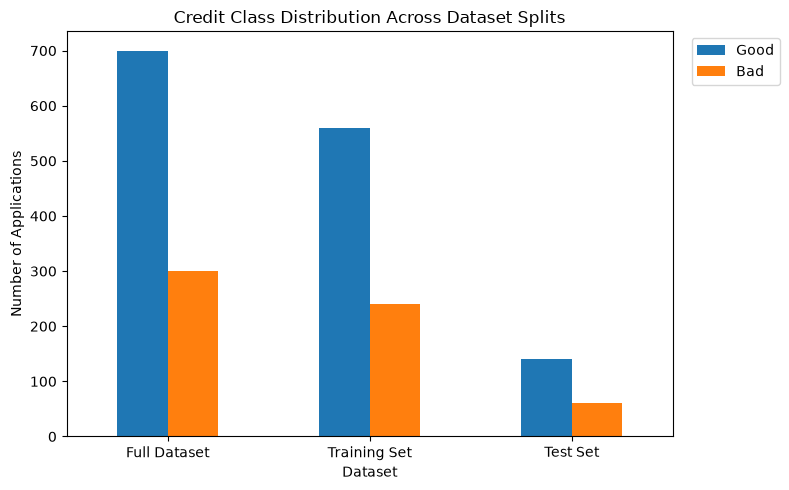

In [34]:
split_distribution_plot = split_distribution.set_index(
    "Dataset"
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = split_distribution_plot.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Credit Class Distribution Across Dataset Splits")
ax.set_xlabel("Dataset")
ax.set_ylabel("Number of Applications")
ax.tick_params(axis="x", rotation=0)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

fig.tight_layout()

chart_path = output_dir / "credit_class_distribution_splits.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 20. Classification Baseline

A majority-class baseline is established before training any predictive
model.

The baseline always predicts the most frequent class observed in the
training data. This provides a minimum reference point against which the
more sophisticated models can be evaluated.

Because the German Credit dataset is imbalanced, accuracy alone is not
sufficient for judging model quality. Precision, recall, F1, and ROC-AUC
will also be reported.

In [35]:

baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(
    X_train,
    y_train
)

baseline_predictions = baseline_model.predict(
    X_test
)

In [36]:
baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_precision = precision_score(
    y_test,
    baseline_predictions,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    baseline_predictions,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    baseline_predictions,
    zero_division=0
)

baseline_probabilities = baseline_model.predict_proba(
    X_test
)[:, 1]

baseline_roc_auc = roc_auc_score(
    y_test,
    baseline_probabilities
)

In [37]:
display(
    Markdown(
        f"""
### 20.1 Baseline Performance

| Metric | Score |
|---|---:|
| Accuracy | **{baseline_accuracy:.6f}** |
| Precision | **{baseline_precision:.6f}** |
| Recall | **{baseline_recall:.6f}** |
| F1 | **{baseline_f1:.6f}** |
| ROC-AUC | **{baseline_roc_auc:.6f}** |

The baseline establishes the minimum reference point that the predictive
models should be compared against.
"""
    )
)


### 20.1 Baseline Performance

| Metric | Score |
|---|---:|
| Accuracy | **0.700000** |
| Precision | **0.700000** |
| Recall | **1.000000** |
| F1 | **0.823529** |
| ROC-AUC | **0.500000** |

The baseline establishes the minimum reference point that the predictive
models should be compared against.


## 21. Logistic Regression

Logistic Regression is trained as the first predictive classification model.

The model is placed after the preprocessing transformer in a scikit-learn
Pipeline. This ensures that categorical encoding is learned from the
training data and applied consistently to both training and test
observations.

The model also provides predicted probabilities, which will later be used
for ROC-AUC evaluation and calibration analysis.

In [38]:
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['checking_status','duration','credit_history',...,'num_dependents', 'own_telephone','foreign_worker']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By

In [39]:
logistic_predictions = logistic_model.predict(
    X_test
)

logistic_probabilities = logistic_model.predict_proba(
    X_test
)[:, 1]

In [40]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions,
    zero_division=0
)

logistic_roc_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

In [41]:
display(
    Markdown(
        f"""
### 21.1 Logistic Regression Performance After Scaling

| Metric | Score |
|---|---:|
| Accuracy | **{logistic_accuracy:.6f}** |
| Precision | **{logistic_precision:.6f}** |
| Recall | **{logistic_recall:.6f}** |
| F1 | **{logistic_f1:.6f}** |
| ROC-AUC | **{logistic_roc_auc:.6f}** |

The numerical features are now standardized within the preprocessing
pipeline, and the Logistic Regression model is trained using the scaled
feature representation.
"""
    )
)


### 21.1 Logistic Regression Performance After Scaling

| Metric | Score |
|---|---:|
| Accuracy | **0.700000** |
| Precision | **0.781690** |
| Recall | **0.792857** |
| F1 | **0.787234** |
| ROC-AUC | **0.750119** |

The numerical features are now standardized within the preprocessing
pipeline, and the Logistic Regression model is trained using the scaled
feature representation.


## 22. Random Forest Classifier

A Random Forest Classifier is trained as the second predictive model.

Random Forest is an ensemble of decision trees. Instead of relying on one
tree, it combines predictions from many trees, which can provide more stable
and robust predictions.

Unlike Logistic Regression, Random Forest does not require numerical
features to be standardized. Therefore, numerical features will pass through
unchanged while categorical features will still be one-hot encoded.

A separate preprocessing pipeline is used so that each model receives
appropriate preprocessing without mixing model-specific assumptions.

In [42]:
forest_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

In [43]:
random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            forest_preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

In [44]:
random_forest_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['checking_status','duration','credit_history',...,'num_dependents', 'own_telephone','foreign_worker']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By

In [45]:
forest_predictions = random_forest_model.predict(
    X_test
)

forest_probabilities = random_forest_model.predict_proba(
    X_test
)[:, 1]

In [46]:
forest_accuracy = accuracy_score(
    y_test,
    forest_predictions
)

forest_precision = precision_score(
    y_test,
    forest_predictions,
    zero_division=0
)

forest_recall = recall_score(
    y_test,
    forest_predictions,
    zero_division=0
)

forest_f1 = f1_score(
    y_test,
    forest_predictions,
    zero_division=0
)

forest_roc_auc = roc_auc_score(
    y_test,
    forest_probabilities
)

In [47]:
display(
    Markdown(
        f"""
### 22.1 Random Forest Performance

| Metric | Score |
|---|---:|
| Accuracy | **{forest_accuracy:.6f}** |
| Precision | **{forest_precision:.6f}** |
| Recall | **{forest_recall:.6f}** |
| F1 | **{forest_f1:.6f}** |
| ROC-AUC | **{forest_roc_auc:.6f}** |
"""
    )
)


### 22.1 Random Forest Performance

| Metric | Score |
|---|---:|
| Accuracy | **0.735000** |
| Precision | **0.777070** |
| Recall | **0.871429** |
| F1 | **0.821549** |
| ROC-AUC | **0.797798** |


## 23. Model Comparison

The Logistic Regression and Random Forest models are compared using the
same held-out test set and the same evaluation metrics.

Using the same test set ensures that differences in performance can be
attributed to the models rather than differences in evaluation data.

In [48]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        forest_accuracy
    ],
    "Precision": [
        logistic_precision,
        forest_precision
    ],
    "Recall": [
        logistic_recall,
        forest_recall
    ],
    "F1": [
        logistic_f1,
        forest_f1
    ],
    "ROC-AUC": [
        logistic_roc_auc,
        forest_roc_auc
    ]
})

display(model_comparison)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.700,0.78169,0.792857,0.787234,0.750119
1,Random Forest,0.735,0.77707,0.871429,0.821549,0.797798


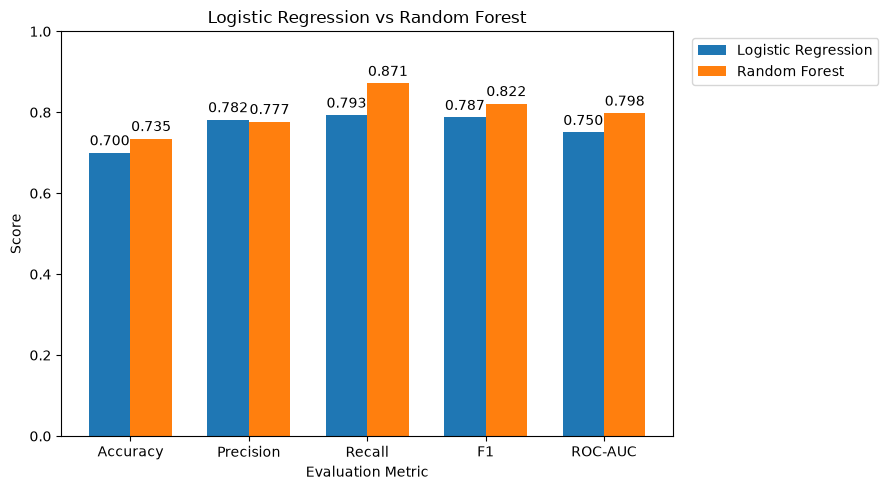

In [49]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

logistic_bars = ax.bar(
    x - width / 2,
    model_comparison.loc[0, metrics],
    width,
    label="Logistic Regression"
)

forest_bars = ax.bar(
    x + width / 2,
    model_comparison.loc[1, metrics],
    width,
    label="Random Forest"
)

ax.bar_label(
    logistic_bars,
    fmt="%.3f",
    padding=3
)

ax.bar_label(
    forest_bars,
    fmt="%.3f",
    padding=3
)

ax.set_title("Logistic Regression vs Random Forest")
ax.set_xlabel("Evaluation Metric")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

fig.tight_layout()

chart_path = output_dir / "logistic_vs_random_forest.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [50]:
forest_accuracy_change = (
    forest_accuracy - logistic_accuracy
)

forest_precision_change = (
    forest_precision - logistic_precision
)

forest_recall_change = (
    forest_recall - logistic_recall
)

forest_f1_change = (
    forest_f1 - logistic_f1
)

forest_roc_auc_change = (
    forest_roc_auc - logistic_roc_auc
)

In [51]:
display(
    Markdown(
        f"""
### 23.1 Random Forest Change Relative to Logistic Regression

Compared with Logistic Regression, Random Forest changes the evaluation
metrics by:

- Accuracy: **{forest_accuracy_change:+.6f}**
- Precision: **{forest_precision_change:+.6f}**
- Recall: **{forest_recall_change:+.6f}**
- F1: **{forest_f1_change:+.6f}**
- ROC-AUC: **{forest_roc_auc_change:+.6f}**

These differences will be considered together when selecting the final model.
No single metric will be used in isolation.
"""
    )
)


### 23.1 Random Forest Change Relative to Logistic Regression

Compared with Logistic Regression, Random Forest changes the evaluation
metrics by:

- Accuracy: **+0.035000**
- Precision: **-0.004620**
- Recall: **+0.078571**
- F1: **+0.034315**
- ROC-AUC: **+0.047679**

These differences will be considered together when selecting the final model.
No single metric will be used in isolation.


## 24. Full Classification Comparison

The majority-class baseline is added to the predictive models so that the
final comparison shows whether the trained models provide meaningful
improvement over a model that simply predicts the most frequent class.

In [52]:
classification_comparison = pd.DataFrame({
    "Model": [
        "Majority Baseline",
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        baseline_accuracy,
        logistic_accuracy,
        forest_accuracy
    ],
    "Precision": [
        baseline_precision,
        logistic_precision,
        forest_precision
    ],
    "Recall": [
        baseline_recall,
        logistic_recall,
        forest_recall
    ],
    "F1": [
        baseline_f1,
        logistic_f1,
        forest_f1
    ],
    "ROC-AUC": [
        baseline_roc_auc,
        logistic_roc_auc,
        forest_roc_auc
    ]
})

display(classification_comparison)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Majority Baseline,0.700,0.70000,1.000000,0.823529,0.500000
1,Logistic Regression,0.700,0.78169,0.792857,0.787234,0.750119
2,Random Forest,0.735,0.77707,0.871429,0.821549,0.797798


In [53]:
predictive_models = classification_comparison[
    classification_comparison["Model"] != "Majority Baseline"
].copy()

best_model_row = predictive_models.loc[
    predictive_models["F1"].idxmax()
]

best_model = best_model_row["Model"]
best_accuracy = best_model_row["Accuracy"]
best_precision = best_model_row["Precision"]
best_recall = best_model_row["Recall"]
best_f1 = best_model_row["F1"]
best_roc_auc = best_model_row["ROC-AUC"]

In [54]:
display(
    Markdown(
        f"""
### 24.1 Final Model Selection

The majority-class baseline is retained as a reference point but is not
considered a candidate for the final predictive model because it does not
learn relationships between the applicant features and credit-risk outcome.

Among the actual predictive models, **{best_model}** achieved the highest
held-out F1 score.

It achieved:

- Accuracy: **{best_accuracy:.6f}**
- Precision: **{best_precision:.6f}**
- Recall: **{best_recall:.6f}**
- F1: **{best_f1:.6f}**
- ROC-AUC: **{best_roc_auc:.6f}**

Random Forest provides a stronger overall result than Logistic Regression,
particularly in recall and ROC-AUC, while maintaining a comparable precision.
Therefore, Random Forest is selected as the final model for the subsequent
error analysis and calibration stages.
"""
    )
)


### 24.1 Final Model Selection

The majority-class baseline is retained as a reference point but is not
considered a candidate for the final predictive model because it does not
learn relationships between the applicant features and credit-risk outcome.

Among the actual predictive models, **Random Forest** achieved the highest
held-out F1 score.

It achieved:

- Accuracy: **0.735000**
- Precision: **0.777070**
- Recall: **0.871429**
- F1: **0.821549**
- ROC-AUC: **0.797798**

Random Forest provides a stronger overall result than Logistic Regression,
particularly in recall and ROC-AUC, while maintaining a comparable precision.
Therefore, Random Forest is selected as the final model for the subsequent
error analysis and calibration stages.


## 25. Error Analysis

The selected Random Forest model is examined at the individual-observation
level to understand where its predictions fail.

The analysis distinguishes between false positives and false negatives.
Because `good` is the positive class, a false positive occurs when the model
predicts an applicant as good when the actual class is bad.

A false negative occurs when the model predicts an applicant as bad when the
actual class is good.

In [55]:
error_analysis = df.loc[
    y_test.index,
    [
        "duration",
        "credit_amount",
        "installment_commitment",
        "residence_since",
        "age",
        "existing_credits",
        "num_dependents",
        "checking_status",
        "credit_history",
        "purpose",
        "savings_status",
        "employment",
        "other_parties",
        "property_magnitude",
        "other_payment_plans",
        "housing",
        "job",
        "own_telephone",
        "foreign_worker",
        "class",
        "target"
    ]
].copy()

error_analysis["predicted_target"] = forest_predictions

error_analysis["correct"] = (
    error_analysis["target"]
    == error_analysis["predicted_target"]
)

In [56]:
misclassified = error_analysis.loc[
    ~error_analysis["correct"]
].copy()

false_positives = misclassified[
    (misclassified["target"] == 0)
    & (misclassified["predicted_target"] == 1)
]

false_negatives = misclassified[
    (misclassified["target"] == 1)
    & (misclassified["predicted_target"] == 0)
]

In [57]:
false_positive_count = len(false_positives)
false_negative_count = len(false_negatives)
total_misclassified = len(misclassified)

display(
    Markdown(
        f"""
### 25.1 Classification Errors

The Random Forest made **{total_misclassified} misclassified predictions**
on the test set.

These consisted of:

- **{false_positive_count} false positives**
- **{false_negative_count} false negatives**
"""
    )
)


### 25.1 Classification Errors

The Random Forest made **53 misclassified predictions**
on the test set.

These consisted of:

- **35 false positives**
- **18 false negatives**


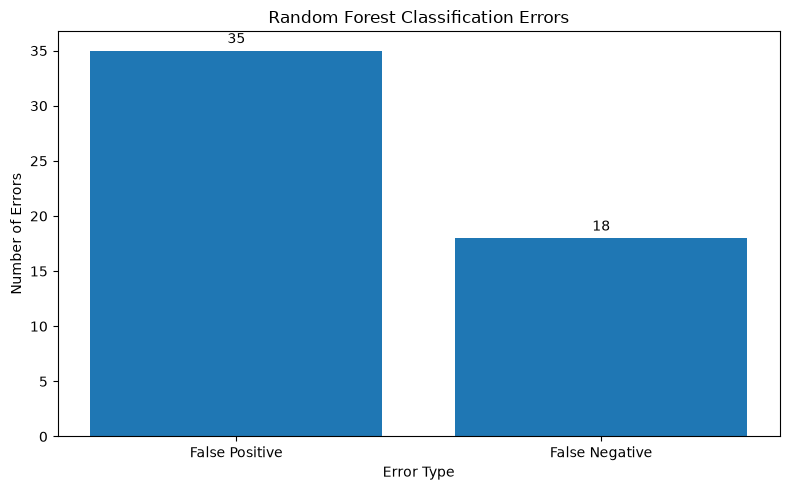

In [58]:
error_counts = pd.DataFrame({
    "Error Type": [
        "False Positive",
        "False Negative"
    ],
    "Count": [
        false_positive_count,
        false_negative_count
    ]
})

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    error_counts["Error Type"],
    error_counts["Count"]
)

ax.bar_label(
    bars,
    padding=3
)

ax.set_title("Random Forest Classification Errors")
ax.set_xlabel("Error Type")
ax.set_ylabel("Number of Errors")

fig.tight_layout()

chart_path = output_dir / "random_forest_classification_errors.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [59]:
false_positives[
    [
        "duration",
        "credit_amount",
        "checking_status",
        "credit_history",
        "purpose",
        "savings_status",
        "employment",
        "class",
        "predicted_target"
    ]
]

,duration,credit_amount,checking_status,credit_history,purpose,savings_status,employment,class,predicted_target
563,36,12389,0<=X<200,existing paid,new car,no known savings,1<=X<4,bad,1
624,18,2600,<0,existing paid,radio/tv,<100,1<=X<4,bad,1
475,18,3114,<0,no credits/all paid,furniture/equipment,<100,<1,bad,1
633,9,1980,no checking,existing paid,furniture/equipment,<100,<1,bad,1
192,27,3915,0<=X<200,existing paid,business,<100,1<=X<4,bad,1
190,24,4591,no checking,existing paid,business,>=1000,1<=X<4,bad,1
56,12,6468,0<=X<200,existing paid,radio/tv,no known savings,unemployed,bad,1
474,18,1245,0<=X<200,critical/other existing credit,radio/tv,<100,1<=X<4,bad,1
381,18,12976,0<=X<200,existing paid,used car,<100,unemployed,bad,1
834,15,2327,>=200,existing paid,radio/tv,<100,<1,bad,1


In [60]:
false_negatives[
    [
        "duration",
        "credit_amount",
        "checking_status",
        "credit_history",
        "purpose",
        "savings_status",
        "employment",
        "class",
        "predicted_target"
    ]
]

,duration,credit_amount,checking_status,credit_history,purpose,savings_status,employment,class,predicted_target
735,36,3990,0<=X<200,all paid,domestic appliance,no known savings,<1,good,0
615,48,12204,0<=X<200,no credits/all paid,business,no known savings,1<=X<4,good,0
36,48,6110,no checking,critical/other existing credit,education,<100,1<=X<4,good,0
217,36,3913,>=200,existing paid,radio/tv,<100,1<=X<4,good,0
31,24,4020,<0,existing paid,furniture/equipment,<100,1<=X<4,good,0
395,39,11760,0<=X<200,delayed previously,education,100<=X<500,4<=X<7,good,0
929,12,1344,<0,delayed previously,new car,<100,1<=X<4,good,0
876,18,1940,<0,all paid,radio/tv,<100,<1,good,0
340,24,5743,0<=X<200,critical/other existing credit,education,<100,<1,good,0
818,36,15857,<0,existing paid,other,<100,unemployed,good,0


In [61]:
false_positive_percentage = (
    false_positive_count / total_misclassified * 100
    if total_misclassified > 0
    else 0
)

false_negative_percentage = (
    false_negative_count / total_misclassified * 100
    if total_misclassified > 0
    else 0
)

display(
    Markdown(
        f"""
### 25.2 Finding

The Random Forest produced **{false_positive_count} false positives**
(**{false_positive_percentage:.2f}%** of all classification errors) and
**{false_negative_count} false negatives**
(**{false_negative_percentage:.2f}%** of all classification errors).

The error distribution shows whether the model's mistakes are concentrated
more strongly in one error type. Individual misclassified observations are
examined above to identify potential patterns in financial characteristics
and categorical applicant attributes.

Because this is a real dataset, these patterns should be treated as
observations about the test sample rather than universal rules about credit
risk.
"""
    )
)


### 25.2 Finding

The Random Forest produced **35 false positives**
(**66.04%** of all classification errors) and
**18 false negatives**
(**33.96%** of all classification errors).

The error distribution shows whether the model's mistakes are concentrated
more strongly in one error type. Individual misclassified observations are
examined above to identify potential patterns in financial characteristics
and categorical applicant attributes.

Because this is a real dataset, these patterns should be treated as
observations about the test sample rather than universal rules about credit
risk.


### 26 Quantitative Error Analysis

The false-positive and false-negative groups are summarized using selected
numerical features.

The purpose is to identify potential differences between the two types of
mistakes without treating observations from the test set as causal evidence.

In [62]:
error_summary = pd.DataFrame({
    "Error Type": [
        "False Positive",
        "False Negative"
    ],
    "Count": [
        len(false_positives),
        len(false_negatives)
    ],
    "Mean Duration": [
        false_positives["duration"].mean(),
        false_negatives["duration"].mean()
    ],
    "Mean Credit Amount": [
        false_positives["credit_amount"].mean(),
        false_negatives["credit_amount"].mean()
    ],
    "Mean Installment Commitment": [
        false_positives["installment_commitment"].mean(),
        false_negatives["installment_commitment"].mean()
    ]
})

display(error_summary)

,Error Type,Count,Mean Duration,Mean Credit Amount,Mean Installment Commitment
0,False Positive,35,23.714286,4701.000000,2.714286
1,False Negative,18,29.333333,5096.166667,2.833333


In [63]:
credit_history_errors = pd.concat(
    [
        false_positives.assign(
            error_type="False Positive"
        ),
        false_negatives.assign(
            error_type="False Negative"
        )
    ]
)

credit_history_error_counts = pd.crosstab(
    credit_history_errors["credit_history"],
    credit_history_errors["error_type"]
)

display(credit_history_error_counts)

error_type,False Negative,False Positive
credit_history,,
all paid,3,4
critical/other existing credit,2,6
delayed previously,4,4
existing paid,8,18
no credits/all paid,1,3


In [64]:
checking_status_error_counts = pd.crosstab(
    credit_history_errors["checking_status"],
    credit_history_errors["error_type"]
)

display(checking_status_error_counts)

error_type,False Negative,False Positive
checking_status,,
0<=X<200,8,14
<0,7,11
>=200,2,2
no checking,1,8


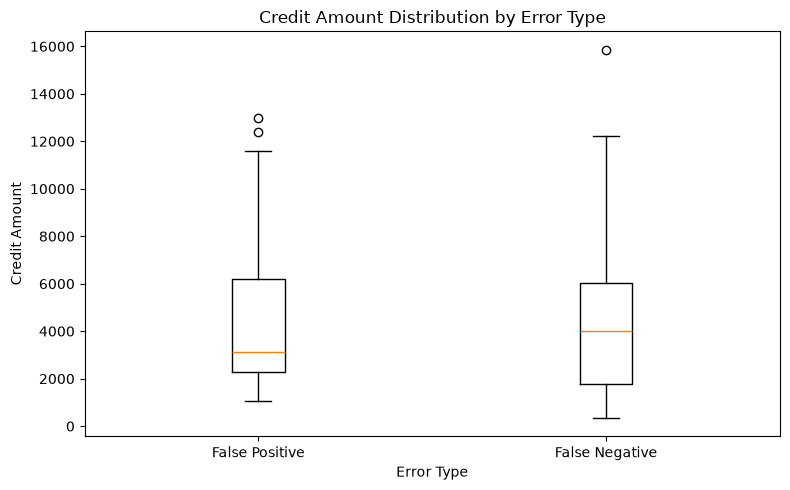

In [65]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.boxplot(
    [
        false_positives["credit_amount"],
        false_negatives["credit_amount"]
    ],
    tick_labels=[
        "False Positive",
        "False Negative"
    ]
)

ax.set_title("Credit Amount Distribution by Error Type")
ax.set_xlabel("Error Type")
ax.set_ylabel("Credit Amount")

fig.tight_layout()

chart_path = output_dir / "random_forest_error_credit_amount.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [66]:
fp_mean_credit = false_positives["credit_amount"].mean()
fn_mean_credit = false_negatives["credit_amount"].mean()

fp_mean_duration = false_positives["duration"].mean()
fn_mean_duration = false_negatives["duration"].mean()

display(
    Markdown(
        f"""
### 26.1 Finding

The Random Forest produced **{false_positive_count} false positives** and
**{false_negative_count} false negatives**.

The false-positive group had an average credit amount of
**{fp_mean_credit:.2f}**, compared with **{fn_mean_credit:.2f}** for the
false-negative group.

The average loan duration was **{fp_mean_duration:.2f}** months for false
positives and **{fn_mean_duration:.2f}** months for false negatives.

The error analysis indicates that the model makes both types of mistakes
across a range of applicant characteristics. False positives are more
frequent than false negatives in this test set, but the observed patterns
should be treated as descriptive rather than causal because they are based
on a limited held-out sample.
"""
    )
)


### 26.1 Finding

The Random Forest produced **35 false positives** and
**18 false negatives**.

The false-positive group had an average credit amount of
**4701.00**, compared with **5096.17** for the
false-negative group.

The average loan duration was **23.71** months for false
positives and **29.33** months for false negatives.

The error analysis indicates that the model makes both types of mistakes
across a range of applicant characteristics. False positives are more
frequent than false negatives in this test set, but the observed patterns
should be treated as descriptive rather than causal because they are based
on a limited held-out sample.


## 27. Calibration

The Random Forest's predicted probabilities are evaluated to determine
whether its confidence estimates correspond reasonably well to observed
outcomes.

A well-calibrated model should produce probabilities that approximately
match the observed frequency of the positive class.

In [67]:
forest_probabilities[:10]

array([0.845, 0.495, 0.495, 0.81 , 0.6  , 0.61 , 0.865, 0.565, 0.505,
       0.725])

In [68]:
calibration_fraction_of_positives, calibration_mean_predicted_value = (
    calibration_curve(
        y_test,
        forest_probabilities,
        n_bins=10,
        strategy="uniform"
    )
)

In [69]:
calibration_results = pd.DataFrame({
    "Mean Predicted Probability": (
        calibration_mean_predicted_value
    ),
    "Actual Fraction of Positives": (
        calibration_fraction_of_positives
    )
})

calibration_results["Calibration Gap"] = (
    calibration_results["Actual Fraction of Positives"]
    - calibration_results["Mean Predicted Probability"]
)

calibration_results["Absolute Calibration Gap"] = (
    calibration_results["Calibration Gap"].abs()
)

display(calibration_results)

,Mean Predicted Probability,Actual Fraction of Positives,Calibration Gap,Absolute Calibration Gap
0,0.258333,0.000000,-0.258333,0.258333
1,0.359333,0.333333,-0.026000,0.026000
2,0.453000,0.520000,0.067000,0.067000
3,0.552407,0.481481,-0.070926,0.070926
4,0.652639,0.666667,0.014028,0.014028
5,0.749394,0.818182,0.068788,0.068788
6,0.855000,0.923077,0.068077,0.068077
7,0.943864,1.000000,0.056136,0.056136


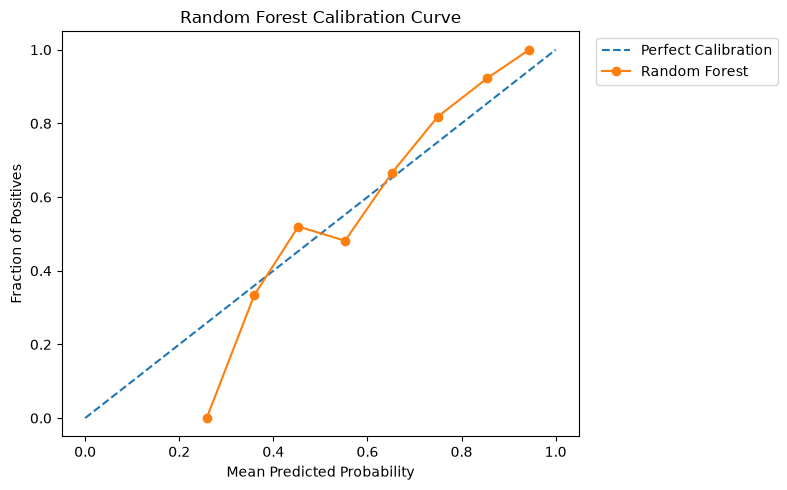

In [70]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

ax.plot(
    calibration_mean_predicted_value,
    calibration_fraction_of_positives,
    marker="o",
    label="Random Forest"
)

ax.set_title("Random Forest Calibration Curve")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

fig.tight_layout()

chart_path = output_dir / "random_forest_calibration_curve.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [71]:
mean_absolute_calibration_gap = (
    calibration_results["Absolute Calibration Gap"].mean()
)

maximum_calibration_gap = (
    calibration_results["Absolute Calibration Gap"].max()
)

weakest_calibration_index = (
    calibration_results["Absolute Calibration Gap"].idxmax()
)

weakest_calibration_predicted = (
    calibration_results.loc[
        weakest_calibration_index,
        "Mean Predicted Probability"
    ]
)

weakest_calibration_actual = (
    calibration_results.loc[
        weakest_calibration_index,
        "Actual Fraction of Positives"
    ]
)

In [72]:
display(
    Markdown(
        f"""
### 27.1 Finding

The Random Forest has a mean absolute calibration gap of
**{mean_absolute_calibration_gap:.6f}** across the non-empty probability
bins.

The maximum calibration gap is **{maximum_calibration_gap:.6f}**.

The weakest calibration occurs around a mean predicted probability of
**{weakest_calibration_predicted:.6f}**, where the observed fraction of
positive outcomes is **{weakest_calibration_actual:.6f}**.

A positive calibration gap indicates that the observed fraction of good
outcomes is higher than the model's predicted probability, while a negative
gap indicates that the model is overestimating the probability.

The calibration curve should therefore be interpreted as evidence about the
reliability of the model's confidence estimates, rather than as another
measure of classification accuracy.
"""
    )
)


### 27.1 Finding

The Random Forest has a mean absolute calibration gap of
**0.078661** across the non-empty probability
bins.

The maximum calibration gap is **0.258333**.

The weakest calibration occurs around a mean predicted probability of
**0.258333**, where the observed fraction of
positive outcomes is **0.000000**.

A positive calibration gap indicates that the observed fraction of good
outcomes is higher than the model's predicted probability, while a negative
gap indicates that the model is overestimating the probability.

The calibration curve should therefore be interpreted as evidence about the
reliability of the model's confidence estimates, rather than as another
measure of classification accuracy.


## 28. Final Reflection

Working with the German Credit dataset was different from working with the
synthetic datasets used earlier in the week.

The synthetic datasets provided controlled relationships between features
and targets, making it easier to understand what the models should discover.
The German Credit dataset required more judgment because the feature
relationships were not known in advance.

The main challenges were categorical feature engineering, deciding how to
handle `personal_status`, dealing with class imbalance, and interpreting
model errors without assuming that observed patterns imply causation.

Another important difference was model evaluation. The majority-class
baseline achieved a strong F1 score because the target is imbalanced, even
though it has no meaningful ability to distinguish between good and bad
credit risks. This reinforced the importance of considering multiple
metrics, particularly ROC-AUC, precision, recall, and F1, rather than
relying on accuracy or a single metric.

The exercise also demonstrated why error analysis and calibration are
important. Aggregate metrics describe overall performance, while individual
errors and predicted probabilities provide additional information about how
the model behaves in practice.

Overall, the German Credit dataset showed that real-world machine learning
requires more judgment and explicit assumptions than a controlled synthetic
dataset. The pipeline remains the same, but the decisions made within the
pipeline become much more important.

In [73]:
display(
    Markdown(
        """
### What I learned from real data

Working with the German Credit dataset was different from working with
synthetic data because the feature space contained many categorical
variables, uneven category frequencies, and a real class imbalance.

The preprocessing pipeline therefore became an important part of the
model rather than something that could be treated as an afterthought.
Encoding categorical variables, scaling numerical variables for Logistic
Regression, and making an explicit decision about `personal_status` showed
how modeling choices can affect both performance and fairness.

The comparison also showed why accuracy alone is insufficient. The
majority baseline achieved strong-looking accuracy simply by predicting
the majority class, while its ROC-AUC showed that it had no discriminatory
ability.
"""
    )
)


### What I learned from real data

Working with the German Credit dataset was different from working with
synthetic data because the feature space contained many categorical
variables, uneven category frequencies, and a real class imbalance.

The preprocessing pipeline therefore became an important part of the
model rather than something that could be treated as an afterthought.
Encoding categorical variables, scaling numerical variables for Logistic
Regression, and making an explicit decision about `personal_status` showed
how modeling choices can affect both performance and fairness.

The comparison also showed why accuracy alone is insufficient. The
majority baseline achieved strong-looking accuracy simply by predicting
the majority class, while its ROC-AUC showed that it had no discriminatory
ability.


In [74]:
display(
    Markdown(
        f"""
### Model comparison

The Logistic Regression model achieved an F1 score of
**{classification_comparison.loc[classification_comparison["Model"] == "Logistic Regression", "F1"].iloc[0]:.6f}**
and ROC-AUC of
**{classification_comparison.loc[classification_comparison["Model"] == "Logistic Regression", "ROC-AUC"].iloc[0]:.6f}**.

The Random Forest achieved an F1 score of
**{classification_comparison.loc[classification_comparison["Model"] == "Random Forest", "F1"].iloc[0]:.6f}**
and ROC-AUC of
**{classification_comparison.loc[classification_comparison["Model"] == "Random Forest", "ROC-AUC"].iloc[0]:.6f}**.

Among the predictive models tested, Random Forest was selected because it
provided the strongest overall balance of accuracy, recall, F1, and
ROC-AUC.
"""
    )
)


### Model comparison

The Logistic Regression model achieved an F1 score of
**0.787234**
and ROC-AUC of
**0.750119**.

The Random Forest achieved an F1 score of
**0.821549**
and ROC-AUC of
**0.797798**.

Among the predictive models tested, Random Forest was selected because it
provided the strongest overall balance of accuracy, recall, F1, and
ROC-AUC.


In [75]:
display(
    Markdown(
        f"""
### Error and calibration lessons

The selected Random Forest produced **{len(misclassified)}** incorrect
predictions on the test set, consisting of **{len(false_positives)}**
false positives and **{len(false_negatives)}** false negatives.

False positives represented
**{len(false_positives) / len(misclassified) * 100:.2f}%** of the
observed errors, while false negatives represented
**{len(false_negatives) / len(misclassified) * 100:.2f}%**.

The calibration analysis also showed that classification performance and
probability reliability are different concepts. The model achieved useful
discrimination, but its predicted probabilities were not perfectly
calibrated, with a mean absolute calibration gap of
**{mean_absolute_calibration_gap:.6f}**.

This reinforced the importance of evaluating a model from multiple
perspectives rather than relying on a single metric.
"""
    )
)


### Error and calibration lessons

The selected Random Forest produced **53** incorrect
predictions on the test set, consisting of **35**
false positives and **18** false negatives.

False positives represented
**66.04%** of the
observed errors, while false negatives represented
**33.96%**.

The calibration analysis also showed that classification performance and
probability reliability are different concepts. The model achieved useful
discrimination, but its predicted probabilities were not perfectly
calibrated, with a mean absolute calibration gap of
**0.078661**.

This reinforced the importance of evaluating a model from multiple
perspectives rather than relying on a single metric.


In [76]:
display(
    Markdown(
        """
### Real data vs synthetic data

Real-world data introduces challenges that are often simplified in
synthetic datasets. These include uneven category frequencies, ambiguous
or sensitive attributes, class imbalance, and the need to make defensible
feature-engineering decisions.

Synthetic data is useful for learning the mechanics of a machine-learning
pipeline because the relationships between variables can be easier to
control and understand. Real data, however, provides a more realistic
test of whether the complete workflow handles messy feature distributions,
preprocessing decisions, model errors, and uncertainty.

The main lesson from this exercise is that building a model is only one
part of machine learning. Understanding the data, defining the prediction
target carefully, choosing appropriate preprocessing, evaluating errors,
and questioning the reliability of model probabilities are equally
important.
"""
    )
)


### Real data vs synthetic data

Real-world data introduces challenges that are often simplified in
synthetic datasets. These include uneven category frequencies, ambiguous
or sensitive attributes, class imbalance, and the need to make defensible
feature-engineering decisions.

Synthetic data is useful for learning the mechanics of a machine-learning
pipeline because the relationships between variables can be easier to
control and understand. Real data, however, provides a more realistic
test of whether the complete workflow handles messy feature distributions,
preprocessing decisions, model errors, and uncertainty.

The main lesson from this exercise is that building a model is only one
part of machine learning. Understanding the data, defining the prediction
target carefully, choosing appropriate preprocessing, evaluating errors,
and questioning the reliability of model probabilities are equally
important.


In [77]:
display(
    Markdown(
        f"""
### Final conclusion

The final Random Forest model achieved **{best_model_row["Accuracy"]:.6f}**
accuracy, **{best_model_row["Precision"]:.6f}** precision,
**{best_model_row["Recall"]:.6f}** recall,
**{best_model_row["F1"]:.6f}** F1, and
**{best_model_row["ROC-AUC"]:.6f}** ROC-AUC on the held-out test set.

Overall, the experiment demonstrates a complete real-data ML workflow:
data diagnosis, feature engineering, fairness-aware feature selection,
preprocessing, baseline comparison, model training, evaluation, error
analysis, and probability calibration.
"""
    )
)


### Final conclusion

The final Random Forest model achieved **0.735000**
accuracy, **0.777070** precision,
**0.871429** recall,
**0.821549** F1, and
**0.797798** ROC-AUC on the held-out test set.

Overall, the experiment demonstrates a complete real-data ML workflow:
data diagnosis, feature engineering, fairness-aware feature selection,
preprocessing, baseline comparison, model training, evaluation, error
analysis, and probability calibration.
